# IMPORT LIBRARIES

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os

from numba import njit
import warnings
warnings.filterwarnings('ignore')

##CAMELS-DATA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

data_dir = "/content/drive/MyDrive/CAMELS_GB/"
start_date, end_date = '1990-01-01', '2014-12-31'

print("Loading, filtering, and aligning CSV files...\n")

# 1. Fast Load & Filter
df_pcp = pd.read_csv(f"{data_dir}pcp_mm.csv", index_col=0).loc[start_date:end_date]
df_pet = pd.read_csv(f"{data_dir}pet_mm.csv", index_col=0).loc[start_date:end_date]
df_q   = pd.read_csv(f"{data_dir}q_mmd_obs.csv", index_col=0).loc[start_date:end_date]

# 2. Fast Alignment
common_stations = sorted(list(set(df_pcp.columns) & set(df_pet.columns) & set(df_q.columns)))
df_pcp = df_pcp[common_stations]
df_pet = df_pet[common_stations]
df_q   = df_q[common_stations]

print(f"✅ Data aligned. Total common stations: {len(common_stations)}")

# ============================================
# Memory-Optimized Wrapper Classes
# ============================================
class SimpleArray:
    __slots__ = ['array']  # Prevents massive RAM bloat
    def __init__(self, array):
        self.array = array
    def to_numpy(self):
        return self.array

class StationData:
    __slots__ = ['data']
    def __init__(self, data_dict):
        self.data = data_dict
    def sel(self, dynamic_features=None):
        return SimpleArray(self.data[dynamic_features])

# ============================================
# Ultra-Fast Dictionary Construction
# ============================================
print("Building ds_recent dictionary...\n")

# Convert DataFrames to 2D NumPy matrices once (orders of magnitude faster than column iteration)
pcp_arr = df_pcp.to_numpy()
pet_arr = df_pet.to_numpy()
q_arr   = df_q.to_numpy()
date_arr = pd.to_datetime(df_pcp.index).to_numpy()

# Build the dictionary using fast index slicing
ds_recent = {
    st: StationData({
        'pcp_mm': pcp_arr[:, i],
        'pet_mm': pet_arr[:, i],
        'q_mmd_obs': q_arr[:, i],
        'date': date_arr
    })
    for i, st in enumerate(common_stations)
}

print(f"✅ Dictionary built successfully!")

# ============================================
# Validation Test
# ============================================
test_station = common_stations[0]
print(f"\nTesting data access for station: {test_station}")

Q_obs = ds_recent[test_station].sel(dynamic_features="q_mmd_obs").to_numpy()
P     = ds_recent[test_station].sel(dynamic_features="pcp_mm").to_numpy()
PET   = ds_recent[test_station].sel(dynamic_features="pet_mm").to_numpy()

print(f"✅ Extraction works correctly!")
print(f"   Q_obs shape: {Q_obs.shape}")
print(f"   Q_obs - min: {np.nanmin(Q_obs):.2f}, max: {np.nanmax(Q_obs):.2f}, mean: {np.nanmean(Q_obs):.2f}")
print(f"   Q_obs Missing: {np.sum(np.isnan(Q_obs))} ({np.sum(np.isnan(Q_obs))/len(Q_obs)*100:.1f}%)")

Loading, filtering, and aligning CSV files...

✅ Data aligned. Total common stations: 671
Building ds_recent dictionary...

✅ Dictionary built successfully!

Testing data access for station: 10002
✅ Extraction works correctly!
   Q_obs shape: (9131,)
   Q_obs - min: 0.21, max: 25.04, mean: 1.37
   Q_obs Missing: 0 (0.0%)


Metrics

In [4]:
@njit
def NSE(obs, sim):

    n = len(obs)

    mean_obs = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1

    if count == 0:
        return np.nan

    mean_obs /= count

    num = 0.0
    den = 0.0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i])**2
            den += (obs[i] - mean_obs)**2

    if den == 0:
        return np.nan

    return 1.0 - num / den

import numpy as np
from numba import njit


@njit
def RMSE(obs, sim):

    n = len(obs)

    mse = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            diff = sim[i] - obs[i]
            mse += diff * diff
            count += 1

    if count == 0:
        return np.nan

    return np.sqrt(mse / count)


@njit
def FHV(obs, sim, top_fraction=0.02):

    mask = ~np.isnan(obs) & ~np.isnan(sim)

    obs = obs[mask]
    sim = sim[mask]

    if len(obs) == 0:
        return np.nan

    n_top = int(len(obs) * top_fraction)

    if n_top == 0:
        return np.nan

    idx = np.argsort(obs)[-n_top:]

    return np.sum(sim[idx] - obs[idx]) / np.sum(obs[idx])


@njit
def NSE_low(obs, sim):

    n = len(obs)

    mean_obs = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1

    if count == 0:
        return np.nan

    mean_obs /= count

    num = 0.0
    den = 0.0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += np.abs(sim[i] - obs[i])
            den += np.abs(obs[i] - mean_obs)

    if den == 0:
        return np.nan

    return 1.0 - num / den

In [5]:
## General Parameters of the code
b1_ratio = 0.8
max_missing_ratio = 0.1

stations = list(ds_recent.keys())

In [6]:
grhymolap_param_bound = [(0.5, 3.5), (1e-3, 300.0), (1e-3, 5000.0), (1e-3, 20.0)]

## dt=0.5

In [7]:
calibration_ratios = [0, 0.30, 0.50, 0.70, 0.90, 0.95]

In [8]:
# ============================================
# TIME DISCRETIZATION
# ============================================
dt = 0.5
nsub = int(1.0 / dt)

# ============================================
# COUPLED STORAGE + RUNOFF
# ============================================

@njit
def cGRHyMoLAP_Model(params, Q0, Pn, En):

    MU, LAMBDA, X1, GAMMA = params

    n = len(Pn)

    Q = np.zeros(n)
    S = np.zeros(n)

    Q[0] = Q0
    S[0] = X1 / 2.0

    ratio = 4.0 / 9.0
    c = (1.0 / (4.0 * X1**4)) * ratio**4

    for t in range(n-1):

        Q_day = Q[t]
        S_day = S[t]

        for k in range(nsub):
            # choose forcing
            if k == nsub - 1:
                P_n = Pn[t + 1]
                E_n = En[t + 1]
            else:
                P_n = Pn[t]
                E_n = En[t]

            temp = S_day / X1

            Ps = P_n * (1.0 - temp**2)
            Es = E_n * (2.0 * temp - temp**2)

            perc = c * S_day**5

            # update S (first ODE)
            S_day = S_day + dt * (Ps - Es - perc)
            if S_day < 0:
                S_day = 0.0

            dQ = (
                -(MU / LAMBDA) * Q_day**(2 * MU - 1)
                + GAMMA * (c * S_day**5) * P_n
            )

            Q_day = Q_day + dt * dQ
            if Q_day < 0:
                Q_day = 0.0

        S[t + 1] = S_day
        Q[t + 1] = Q_day

    return Q, S


# ============================================
# STORAGE
# ============================================

results_sensitivity = {}
results_sensitivity_stats = {}

# 👉 NEW: store ONLY validation NSE
nse_val_store = {}

# ============================================
# MAIN LOOP
# ============================================

for cal_ratio in calibration_ratios:

    print(f"\n\n==============================")
    print(f"🔥 Calibration ratio = {cal_ratio:.2f}")
    print(f"==============================\n")

    results_cGRH_exp_02 = {}

    # ============================================
    # LOOP OVER STATIONS
    # ============================================
    for i, station_id in enumerate(stations):

        print(f"\n=== Station {station_id} ({i+1}) ===")

        Q_obs = ds_recent[station_id].sel(
            dynamic_features="q_mmd_obs"
        ).to_numpy()

        P = ds_recent[station_id].sel(
            dynamic_features="pcp_mm"
        ).to_numpy()

        PET = ds_recent[station_id].sel(
            dynamic_features="pet_mm"
        ).to_numpy()

        Pn = np.maximum(0, P - PET)
        En = np.maximum(0, PET - P)

        N = len(Q_obs)

        if N == 0 or np.all(np.isnan(Q_obs)):
            continue

        if np.sum(np.isnan(Q_obs)) / N > max_missing_ratio:
            continue

        # ============================================
        # SPLITS
        # ============================================
        val_start = int(0.7 * N)
        cal_start = int(cal_ratio * val_start)

        Q0 = Q_obs[cal_start]
        if np.isnan(Q0):
            Q0 = 0 #np.nanmean(Q_obs[:10])

        # ============================================
        # OPTIMIZATION
        # ============================================
        best_res = None
        best_val = float("inf")

        initial_guesses = [
            [0.5, 1.0, 80, 0.05],
            [0.7, 2.0, 120, 0.1],
            [1.0, 5.0, 150, 0.2],
            [1.2, 8.0, 250, 0.3],
            [1.5, 10.0, 300, 0.5],
            [2.0, 15.0, 400, 0.8],
            [2.5, 20.0, 600, 1.0],
            [0.8, 3.0, 800, 0.2],
            [1.0, 6.0, 1000, 0.4],
            [3.0, 25.0, 200, 0.1],
            [1.0, 12.0, 1500, 0.6]
        ]

        for guess in initial_guesses:

            res = minimize(
                lambda p: RMSE(
                    Q_obs[cal_start:val_start],
                    cGRHyMoLAP_Model(p, Q0, Pn[cal_start:val_start], En[cal_start:val_start])[0]
                ),
                guess,
                method="Nelder-Mead",
                bounds=grhymolap_param_bound,
                options={'maxiter': 2500, 'disp': False}
            )

            if res.fun < best_val:
                best_val = res.fun
                best_res = res

        # ============================================
        # SIMULATION
        # ============================================
        Qsim, S = cGRHyMoLAP_Model(best_res.x, Q0, Pn, En)

        # ============================================
        # METRICS
        # ============================================
        NSE_cal = NSE(Q_obs[cal_start:val_start], Qsim[cal_start:val_start])
        NSE_val = NSE(Q_obs[val_start:], Qsim[val_start:])

        RMSE_cal = RMSE(Q_obs[cal_start:val_start], Qsim[cal_start:val_start])
        RMSE_val = RMSE(Q_obs[val_start:], Qsim[val_start:])

        FHV_val = FHV(Q_obs[val_start:], Qsim[val_start:])
        NSE_low_val = NSE_low(Q_obs[val_start:], Qsim[val_start:])

        results_cGRH_exp_02[station_id] = {
            "NSE_cal": NSE_cal,
            "NSE_val": NSE_val,
            "RMSE_cal": RMSE_cal,
            "RMSE_val": RMSE_val,
            "FHV_val": FHV_val,
            "NSE_low_val": NSE_low_val,
        }

        # 👉 STORE ONLY VALIDATION NSE
        if cal_ratio not in nse_val_store:
            nse_val_store[cal_ratio] = []

        nse_val_store[cal_ratio].append(NSE_val)

        print(f"   NSE cal: {NSE_cal:.4f}")
        print(f"   NSE val: {NSE_val:.4f}")

    # ============================================
    # STORE RAW
    # ============================================
    results_sensitivity[cal_ratio] = results_cGRH_exp_02

    # ============================================
    # AGGREGATION (MEAN + MEDIAN)
    # ============================================
    nse_cal_list = []
    nse_val_list = []
    rmse_cal_list = []
    rmse_val_list = []

    for st, res in results_cGRH_exp_02.items():

        if res["NSE_cal"] is not None:
            nse_cal_list.append(res["NSE_cal"])
        if res["NSE_val"] is not None:
            nse_val_list.append(res["NSE_val"])
        if res["RMSE_cal"] is not None:
            rmse_cal_list.append(res["RMSE_cal"])
        if res["RMSE_val"] is not None:
            rmse_val_list.append(res["RMSE_val"])

    results_sensitivity_stats[cal_ratio] = {

        "NSE_cal_mean": np.nanmean(nse_cal_list),
        "NSE_cal_median": np.nanmedian(nse_cal_list),

        "NSE_val_mean": np.nanmean(nse_val_list),
        "NSE_val_median": np.nanmedian(nse_val_list),

        "RMSE_cal_mean": np.nanmean(rmse_cal_list),
        "RMSE_cal_median": np.nanmedian(rmse_cal_list),

        "RMSE_val_mean": np.nanmean(rmse_val_list),
        "RMSE_val_median": np.nanmedian(rmse_val_list),
    }

print("\n✅ Sensitivity experiment completed.")

Streaming output truncated to the last 5000 lines.
   NSE cal: 0.8500
   NSE val: 0.6882

=== Station 17018 (49) ===

=== Station 18001 (50) ===
   NSE cal: 0.8452
   NSE val: 0.7083

=== Station 18002 (51) ===
   NSE cal: 0.8218
   NSE val: 0.6772

=== Station 18003 (52) ===
   NSE cal: 0.9327
   NSE val: 0.8709

=== Station 18008 (53) ===
   NSE cal: 0.8902
   NSE val: 0.8476

=== Station 18010 (54) ===

=== Station 18011 (55) ===
   NSE cal: 0.9043
   NSE val: 0.8705

=== Station 18014 (56) ===
   NSE cal: 0.8386
   NSE val: 0.7040

=== Station 18017 (57) ===

=== Station 18018 (58) ===

=== Station 19001 (59) ===
   NSE cal: 0.8682
   NSE val: 0.7811

=== Station 19006 (60) ===
   NSE cal: 0.8082
   NSE val: 0.7424

=== Station 19010 (61) ===

=== Station 19017 (62) ===
   NSE cal: 0.8216
   NSE val: 0.6076

=== Station 19020 (63) ===
   NSE cal: 0.8693
   NSE val: 0.7574

=== Station 20002 (64) ===
   NSE cal: 0.7165
   NSE val: 0.5336

=== Station 20003 (65) ===
   NSE cal: 0.718

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

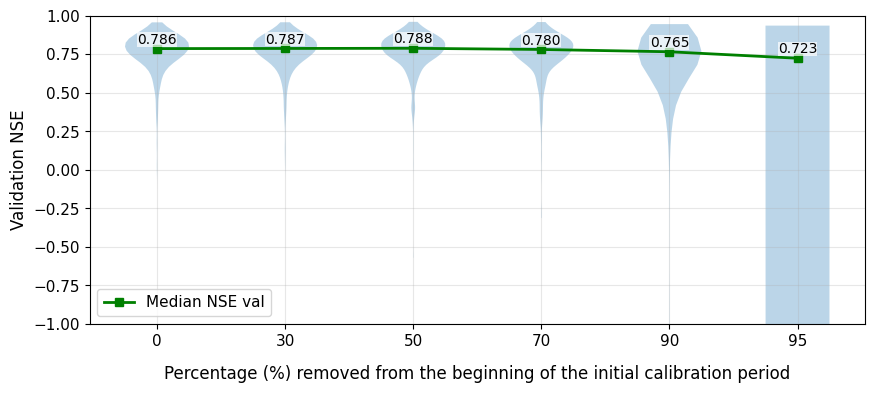

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

ratios = sorted(nse_val_store.keys())
data = [nse_val_store[r] for r in ratios]

medians = [np.median(d) for d in data]

plt.figure(figsize=(10, 4))

vp = plt.violinplot(
    data,
    positions=np.arange(len(ratios)),
    showmeans=False,
    showmedians=False,
    showextrema=False
)

plt.plot(
    np.arange(len(ratios)),
    medians,
    'g-s',
    linewidth=2,
    label="Median NSE val"
)

# Affichage des valeurs des médianes au-dessus des points
for i, med in enumerate(medians):
    plt.text(
        i,
        med + 0.015,
        f"{med:.3f}",
        ha='center',
        va='bottom',
        fontsize=10,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.7,
            pad=0.2
        )
    )

plt.xticks(
    np.arange(len(ratios)),
    [f"{100*r:.0f}" for r in ratios]
)

plt.xlabel(
    "Percentage (%) removed from the beginning of the initial calibration period",
    labelpad=12
)

plt.ylabel("Validation NSE")

#plt.title(
#    "Effect of calibration length on validation performance"
#)

plt.ylim(-1, 1)

plt.legend(loc='lower left')

plt.grid(True, alpha=0.3)

plt.savefig(
    "length.jpeg",
    format="jpeg",
    dpi=700,
    bbox_inches="tight"
)

files.download("length.jpeg")

plt.show()

##Testing other various windows

In [10]:
# ============================================
# TIME DISCRETIZATION
# ============================================
dt = 0.5
nsub = int(1.0 / dt)

# ============================================
# COUPLED STORAGE + RUNOFF
# ============================================

@njit
def cGRHyMoLAP_Model(params, Q0, Pn, En):

    MU, LAMBDA, X1, GAMMA = params

    n = len(Pn)

    Q = np.zeros(n)
    S = np.zeros(n)

    Q[0] = Q0
    S[0] = X1 / 2.0

    ratio = 4.0 / 9.0
    c = (1.0 / (4.0 * X1**4)) * ratio**4

    for t in range(n-1):

        Q_day = Q[t]
        S_day = S[t]

        for k in range(nsub):
            # choose forcing
            if k == nsub - 1:
                P_n = Pn[t + 1]
                E_n = En[t + 1]
            else:
                P_n = Pn[t]
                E_n = En[t]

            temp = S_day / X1

            Ps = P_n * (1.0 - temp**2)
            Es = E_n * (2.0 * temp - temp**2)

            perc = c * S_day**5

            # update S (first ODE)
            S_day = S_day + dt * (Ps - Es - perc)
            if S_day < 0:
                S_day = 0.0

            dQ = (
                -(MU / LAMBDA) * Q_day**(2 * MU - 1)
                + GAMMA * (c * S_day**5) * P_n
            )

            Q_day = Q_day + dt * dQ
            if Q_day < 0:
                Q_day = 0.0

        S[t + 1] = S_day
        Q[t + 1] = Q_day

    return Q, S

# ============================================
# STORAGE
# ============================================

results_sensitivity = {}
results_sensitivity_stats = {}
nse_val_store = {}

# ============================================
# MAIN LOOP (4 CALIBRATION BLOCKS)
# ============================================

n_blocks = 4
block_ids = np.arange(n_blocks)

for block_id in block_ids:

    print(f"\n\n==============================")
    print(f"🔥 Calibration block = {block_id + 1}/{n_blocks}")
    print(f"==============================\n")

    results_cGRH_exp_02 = {}

    # ============================================
    # LOOP OVER STATIONS
    # ============================================
    for i, station_id in enumerate(stations):

        print(f"\n=== Station {station_id} ({i+1}) ===")

        Q_obs = ds_recent[station_id].sel(
            dynamic_features="q_mmd_obs"
        ).to_numpy()

        P = ds_recent[station_id].sel(
            dynamic_features="pcp_mm"
        ).to_numpy()

        PET = ds_recent[station_id].sel(
            dynamic_features="pet_mm"
        ).to_numpy()

        Pn = np.maximum(0, P - PET)
        En = np.maximum(0, PET - P)

        N = len(Q_obs)

        if N == 0 or np.all(np.isnan(Q_obs)):
            continue

        if np.sum(np.isnan(Q_obs)) / N > max_missing_ratio:
            continue

        # ============================================
        # SPLITS
        # ============================================
        val_start = int(0.7 * N)

        cal_length = val_start
        block_size = cal_length // n_blocks

        cal_start = block_id * block_size
        cal_end = (block_id + 1) * block_size if block_id < n_blocks - 1 else val_start

        Q0 = Q_obs[cal_start]
        if np.isnan(Q0):
            Q0 = 0

        # ============================================
        # OPTIMIZATION
        # ============================================
        best_res = None
        best_val = float("inf")

        initial_guesses = [
            [0.5, 1.0, 80, 0.05],
            [0.7, 2.0, 120, 0.1],
            [1.0, 5.0, 150, 0.2],
            [1.2, 8.0, 250, 0.3],
            [1.5, 10.0, 300, 0.5],
            [2.0, 15.0, 400, 0.8],
            [2.5, 20.0, 600, 1.0],
            [0.8, 3.0, 800, 0.2],
            [1.0, 6.0, 1000, 0.4],
            [3.0, 25.0, 200, 0.1],
            [1.0, 12.0, 1500, 0.6]
        ]

        for guess in initial_guesses:

            res = minimize(
                lambda p: RMSE(
                    Q_obs[cal_start:cal_end],
                    cGRHyMoLAP_Model(
                        p,
                        Q0,
                        Pn[cal_start:cal_end],
                        En[cal_start:cal_end]
                    )[0]
                ),
                guess,
                method="Nelder-Mead",
                bounds=grhymolap_param_bound,
                options={'maxiter': 2500, 'disp': False}
            )

            if res.fun < best_val:
                best_val = res.fun
                best_res = res

        # ============================================
        # SIMULATION
        # ============================================
        Qsim, S = cGRHyMoLAP_Model(best_res.x, Q0, Pn, En)

        # ============================================
        # METRICS
        # ============================================
        NSE_cal = NSE(Q_obs[cal_start:cal_end], Qsim[cal_start:cal_end])
        NSE_val = NSE(Q_obs[val_start:], Qsim[val_start:])

        RMSE_cal = RMSE(Q_obs[cal_start:cal_end], Qsim[cal_start:cal_end])
        RMSE_val = RMSE(Q_obs[val_start:], Qsim[val_start:])

        FHV_val = FHV(Q_obs[val_start:], Qsim[val_start:])
        NSE_low_val = NSE_low(Q_obs[val_start:], Qsim[val_start:])

        results_cGRH_exp_02[station_id] = {
            "NSE_cal": NSE_cal,
            "NSE_val": NSE_val,
            "RMSE_cal": RMSE_cal,
            "RMSE_val": RMSE_val,
            "FHV_val": FHV_val,
            "NSE_low_val": NSE_low_val,
        }

        # ============================================
        # STORE VALIDATION NSE
        # ============================================
        if block_id not in nse_val_store:
            nse_val_store[block_id] = []

        nse_val_store[block_id].append(NSE_val)

        print(f"   NSE cal: {NSE_cal:.4f}")
        print(f"   NSE val: {NSE_val:.4f}")

    # ============================================
    # STORE RAW RESULTS
    # ============================================
    results_sensitivity[block_id] = results_cGRH_exp_02

    # ============================================
    # AGGREGATION
    # ============================================
    nse_cal_list = []
    nse_val_list = []
    rmse_cal_list = []
    rmse_val_list = []

    for st, res in results_cGRH_exp_02.items():

        if res["NSE_cal"] is not None:
            nse_cal_list.append(res["NSE_cal"])
        if res["NSE_val"] is not None:
            nse_val_list.append(res["NSE_val"])
        if res["RMSE_cal"] is not None:
            rmse_cal_list.append(res["RMSE_cal"])
        if res["RMSE_val"] is not None:
            rmse_val_list.append(res["RMSE_val"])

    results_sensitivity_stats[block_id] = {

        "NSE_cal_mean": np.nanmean(nse_cal_list),
        "NSE_cal_median": np.nanmedian(nse_cal_list),

        "NSE_val_mean": np.nanmean(nse_val_list),
        "NSE_val_median": np.nanmedian(nse_val_list),

        "RMSE_cal_mean": np.nanmean(rmse_cal_list),
        "RMSE_cal_median": np.nanmedian(rmse_cal_list),

        "RMSE_val_mean": np.nanmean(rmse_val_list),
        "RMSE_val_median": np.nanmedian(rmse_val_list),
    }

print("\n✅ 4-block calibration sensitivity experiment completed.")

Streaming output truncated to the last 5000 lines.
   NSE cal: 0.7667
   NSE val: 0.6668

=== Station 17018 (49) ===

=== Station 18001 (50) ===
   NSE cal: 0.7382
   NSE val: 0.6978

=== Station 18002 (51) ===
   NSE cal: 0.7987
   NSE val: 0.6966

=== Station 18003 (52) ===
   NSE cal: 0.8988
   NSE val: 0.8745

=== Station 18008 (53) ===
   NSE cal: 0.8952
   NSE val: 0.8479

=== Station 18010 (54) ===

=== Station 18011 (55) ===
   NSE cal: 0.9200
   NSE val: 0.8888

=== Station 18014 (56) ===
   NSE cal: 0.8160
   NSE val: 0.7365

=== Station 18017 (57) ===

=== Station 18018 (58) ===

=== Station 19001 (59) ===
   NSE cal: 0.8161
   NSE val: 0.8051

=== Station 19006 (60) ===
   NSE cal: 0.7685
   NSE val: 0.7108

=== Station 19010 (61) ===

=== Station 19017 (62) ===
   NSE cal: 0.8302
   NSE val: 0.6760

=== Station 19020 (63) ===
   NSE cal: 0.8254
   NSE val: 0.7417

=== Station 20002 (64) ===
   NSE cal: 0.8398
   NSE val: 0.5408

=== Station 20003 (65) ===
   NSE cal: 0.823

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

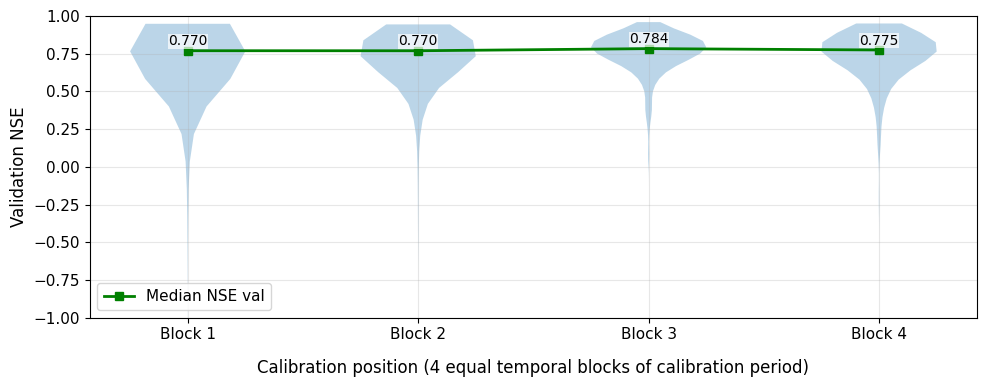

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

# ============================================
# DATA
# ============================================
block_ids = sorted(nse_val_store.keys())
data = [nse_val_store[b] for b in block_ids]

medians = [np.median(d) for d in data]

# ============================================
# PLOT
# ============================================
plt.figure(figsize=(10, 4))

vp = plt.violinplot(
    data,
    positions=np.arange(len(block_ids)),
    showmeans=False,
    showmedians=False,
    showextrema=False
)

plt.plot(
    np.arange(len(block_ids)),
    medians,
    'g-s',
    linewidth=2,
    label="Median NSE val"
)

# ============================================
# MEDIAN LABELS
# ============================================
for i, med in enumerate(medians):
    plt.text(
        i,
        med + 0.015,
        f"{med:.3f}",
        ha='center',
        va='bottom',
        fontsize=10,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.7,
            pad=0.2
        )
    )

# ============================================
# X LABELS (5 calibration blocks)
# ============================================
plt.xticks(
    np.arange(len(block_ids)),
    [f"Block {b+1}" for b in block_ids]
)

plt.xlabel(
    "Calibration position (4 equal temporal blocks of calibration period)",
    labelpad=12
)

plt.ylabel("Validation NSE")

plt.ylim(-1, 1)

plt.legend(loc='lower left')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "length2.jpeg",
    format="jpeg",
    dpi=700,
    bbox_inches="tight"
)

plt.savefig(
    "length11.jpeg",
    format="jpeg",
    dpi=700,
    bbox_inches="tight"
)

files.download("length11.jpeg")

plt.show()